# Assignment 3 – Image Captioning
# Phase 3 (Model 2): ViT-B/16 Encoder + Transformer Decoder

## Insights from Group Discussion

After comparing all Phase 2 architectures across the group, the following patterns emerged:

1. **Transformer decoders outperform GRU/LSTM decoders.** The model using EfficientNet-B4 + Transformer Decoder achieved test BLEU-4: 0.1650 (greedy), comfortably above all RNN-based decoders. Multi-head cross-attention over all spatial positions simultaneously is fundamentally more expressive than sequential recurrence.
2. **`<unk>` suppression gives ~8% free improvement.** A peer observed that suppressing the `<unk>` token score to `-inf` during decoding forces the model to predict the next-best real word instead of outputting unknown tokens, improving all BLEU scores without retraining.
3. **Label smoothing reduces post-peak BLEU drift.** The peer's Transformer model used label smoothing (ε=0.1) which kept validation scores more stable across epochs.

## Phase 3 Architecture: ViT-B/16 + Transformer Decoder

This model takes the encoder from Phase 2 and replaces the GRU decoder with a **4-layer Transformer decoder** (8 heads, d_model=512).

| Component | Phase 2 | Phase 3 | Why changed |
|---|---|---|---|
| Encoder | ViT-B/16, 4 blocks unfrozen | ViT-B/16, **6 blocks unfrozen** | Better VizWiz adaptation |
| Decoder | 2-layer GRU + Luong attention | **4-layer Transformer decoder** | Parallel cross-attention; no sequential bottleneck |
| Loss | CrossEntropy | CrossEntropy + **label smoothing (ε=0.1)** | Reduces overfitting post-peak |
| Decoding | Greedy / beam | Greedy / beam + **`<unk>` suppression** | ~8% BLEU improvement |
| Epochs | 20 (no early stop cap) | **15 max + early stopping (patience=5)** | Prevents post-peak degradation |

## 1. Imports and Configuration

In [ ]:
import os
import json
import pickle
import random
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB


## 2. Load Shared Artefacts from Phase 1

In [ ]:
# Defining Directory
DATA_DIR   = Path("/kaggle/input/datasets/sahaj25585973/vizwiz-images")
IMAGE_DIR  = DATA_DIR / "val"
SHARED_PKL = Path("/kaggle/input/datasets/sahaj25585973/processed-data/shared_data.pkl")
SAVE_DIR   = Path("/kaggle/working/vit_transformer_outputs")
BEST_CKPT  = SAVE_DIR / "vit_transformer_best.pth"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Loading shared data
with open(SHARED_PKL, "rb") as f:
    shared = pickle.load(f)

word2idx         = shared["vocab_word2idx"]
idx2word         = shared["vocab_idx2word"]
train_ids        = shared["train_ids"]
val_ids          = shared["val_ids"]
test_ids         = shared["test_ids"]
cleaned_captions = shared["cleaned_captions"]
id_to_file       = shared["id_to_file"]
MAX_CAPTION_LEN  = shared["max_caption_len"]

VOCAB_SIZE = len(word2idx)
PAD_IDX    = word2idx["<pad>"]
START_IDX  = word2idx["<start>"]
END_IDX    = word2idx["<end>"]
UNK_IDX    = word2idx["<unk>"]

print(f"Vocab size        : {VOCAB_SIZE}")
print(f"Max caption len   : {MAX_CAPTION_LEN}")
print(f"Train / Val / Test: {len(train_ids)} / {len(val_ids)} / {len(test_ids)}")
print(f"PAD={PAD_IDX}  START={START_IDX}  END={END_IDX}  UNK={UNK_IDX}")

Vocab size        : 3519
Max caption len   : 22
Train / Val / Test: 6033 / 754 / 755
PAD=0  START=1  END=2  UNK=3


In [ ]:
# Creating Vocabulary wrapper
class Vocabulary:
    def __init__(self, word2idx, idx2word):
        self.word2idx = word2idx
        self.idx2word = idx2word

    def encode(self, caption: str) -> list:
        tokens = caption.split()
        ids    = [START_IDX]
        ids   += [self.word2idx.get(t, UNK_IDX) for t in tokens]
        ids.append(END_IDX)
        return ids

    def decode(self, indices: list) -> str:
        words = []
        for idx in indices:
            w = self.idx2word.get(int(idx), "<unk>")
            if w == "<end>":
                break
            if w not in ("<pad>", "<start>", "<unk>"):
                words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

vocab = Vocabulary(word2idx, idx2word)
print(f"Vocabulary reconstructed — {len(vocab)} tokens")

Vocabulary reconstructed — 3519 tokens


## 3. Dataset and DataLoaders

In [ ]:
# Transforms & ImageNet normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
class VizWizCaptionDataset(Dataset):
    """
    mode='train' : one (image, caption) pair per caption — flattened.
    mode='eval'  : one row per image, all reference captions returned as strings.
    """
    def __init__(self, image_ids, captions_dict, vocab, id_to_file,
                 image_dir, transform=None, max_len=50, mode="train"):
        self.captions_dict = captions_dict
        self.vocab         = vocab
        self.id_to_file    = id_to_file
        self.image_dir     = Path(image_dir)
        self.transform     = transform
        self.max_len       = max_len
        self.mode          = mode

        if mode == "train":
            self.samples = [
                (img_id, cap)
                for img_id in image_ids
                for cap in captions_dict[img_id]
            ]
        else:
            self.samples = [(img_id, captions_dict[img_id]) for img_id in image_ids]

    def __len__(self):
        return len(self.samples)

    def _load_image(self, img_id):
        path = self.image_dir / self.id_to_file[img_id]
        img  = Image.open(path).convert("RGB")
        return self.transform(img) if self.transform else transforms.ToTensor()(img)

    def __getitem__(self, index):
        if self.mode == "train":
            img_id, caption = self.samples[index]
            img     = self._load_image(img_id)
            encoded = self.vocab.encode(caption)
            length  = min(len(encoded), self.max_len)
            if len(encoded) < self.max_len:
                encoded += [PAD_IDX] * (self.max_len - len(encoded))
            else:
                encoded = encoded[:self.max_len - 1] + [END_IDX]
                length  = self.max_len
            return img, torch.tensor(encoded, dtype=torch.long), length
        else:
            img_id, captions_list = self.samples[index]
            img = self._load_image(img_id)
            return img, captions_list, img_id


def collate_train(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    images, captions, lengths = zip(*batch)
    return (torch.stack(images),
            torch.stack(captions),
            torch.tensor(lengths, dtype=torch.long))


def collate_eval(batch):
    images, all_captions, img_ids = zip(*batch)
    return torch.stack(images), list(all_captions), list(img_ids)


BATCH_SIZE  = 32
NUM_WORKERS = 0

train_dataset = VizWizCaptionDataset(train_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
                                     transform=train_transform, max_len=MAX_CAPTION_LEN, mode="train")

val_dataset = VizWizCaptionDataset(val_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
                                   transform=eval_transform, max_len=MAX_CAPTION_LEN, mode="eval")

test_dataset = VizWizCaptionDataset(test_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
                                    transform=eval_transform, max_len=MAX_CAPTION_LEN, mode="eval")

# Defining DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_train, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_eval, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_eval, pin_memory=False)

print(f"Train samples : {len(train_dataset):,}  ({len(train_loader)} batches)")
print(f"Val   images  : {len(val_dataset):,}")
print(f"Test  images  : {len(test_dataset):,}")

# Sanity check
imgs, caps, lens = next(iter(train_loader))
print(f"\nBatch images   : {imgs.shape}")
print(f"Batch captions : {caps.shape}")
print(f"Sample decoded : '{vocab.decode(caps[0].tolist())}'")

Train samples : 26,436  (827 batches)
Val   images  : 754
Test  images  : 755

Batch images   : torch.Size([32, 3, 224, 224])
Batch captions : torch.Size([32, 22])
Sample decoded : 'the cover of a book with the words written on it along with the picture of a'


## 4. Model Architecture

### 4.1 ViT-B/16 Encoder (6 blocks unfrozen)

In [ ]:
class ViTEncoder(nn.Module):
    def __init__(self, embed_dim: int = 512, n_unfreeze: int = 6):
        super().__init__()
        vit = tv_models.vit_b_16(weights=tv_models.ViT_B_16_Weights.IMAGENET1K_V1)

        self.patch_embedding = vit.conv_proj
        self.class_token     = vit.class_token
        self.pos_embedding   = vit.encoder.pos_embedding
        self.encoder_blocks  = vit.encoder.layers
        self.ln              = vit.encoder.ln

        # Project ViT 768-d tokens → decoder d_model
        self.projection = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.ReLU(),
        )

        # Freeze everything first
        for module in [self.patch_embedding, self.encoder_blocks, self.ln]:
            for p in module.parameters():
                p.requires_grad_(False)
        self.class_token.requires_grad_(False)
        self.pos_embedding.requires_grad_(False)

        # Unfreeze last n_unfreeze transformer blocks
        # ViT-B/16 has 12 encoder blocks total.
        # Phase 2 unfroze blocks 8-11 (last 4).
        # Phase 3 unfreezes blocks 6-11 (last 6) for deeper adaptation.
        num_blocks = len(self.encoder_blocks)
        for i in range(num_blocks - n_unfreeze, num_blocks):
            for p in self.encoder_blocks[i].parameters():
                p.requires_grad_(True)

        # Always train the final LayerNorm and projection
        for p in self.ln.parameters():
            p.requires_grad_(True)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"[ViTEncoder] trainable: {trainable:,} / {total:,} "
              f"({100*trainable/total:.1f}%)  — {n_unfreeze}/12 blocks unfrozen")

    def forward(self, x):
        B = x.size(0)
        # Patchify: conv projection → (B, 768, 14, 14)
        x = self.patch_embedding(x)
        x = x.flatten(2).transpose(1, 2)
        # Prepend CLS token
        cls = self.class_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        # Add positional embedding
        x   = x + self.pos_embedding
        # Transformer encoder blocks
        for block in self.encoder_blocks:
            x = block(x)
        x = self.ln(x)
        # Drop CLS, project to d_model
        patch_feats = self.projection(x[:, 1:, :])  # (B, 196, embed_dim)
        return patch_feats

### 4.2 Sinusoidal Positional Encoding

In [ ]:
# Standard sinusoidal positional encoding added to token embeddings before the Transformer decoder
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 200, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                   # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

### 4.3 Transformer Decoder

In [ ]:
class TransformerDecoder(nn.Module):
    """
    Parameters
    ----------
    vocab_size      : number of tokens
    d_model         : embedding + hidden dimension (must match encoder)
    nhead           : number of attention heads
    num_layers      : number of Transformer decoder layers
    dim_feedforward : inner FFN dimension
    dropout         : dropout probability
    max_len         : maximum caption length for positional encoding
    """
    def __init__(self, vocab_size, d_model=512, nhead=8, num_layers=4,
                 dim_feedforward=2048, dropout=0.1, max_len=200):
        super().__init__()
        self.d_model = d_model

        # Token embedding + positional encoding
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_len, dropout)

        # Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,
        )
        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers = num_layers,
        )

        # Output projection to vocabulary
        self.fc_out = nn.Linear(d_model, vocab_size)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)

    @staticmethod
    def _causal_mask(seq_len, device):
        """
        Upper-triangular causal mask: position i cannot attend to j > i.
        Shape: (seq_len, seq_len), dtype float, -inf for masked positions.
        """
        mask = torch.triu(torch.full((seq_len, seq_len), float("-inf"), device=device), diagonal=1)
        return mask

    @staticmethod
    def _pad_mask(captions, pad_idx):
        """
        Boolean key padding mask for PAD tokens.
        Shape: (B, seq_len)
        """
        return captions == pad_idx

    def forward(self, encoder_out, captions):
        # Input: all tokens except last
        tgt = captions[:, :-1]
        T   = tgt.size(1)

        # Embed + positional encoding
        tgt_emb = self.embedding(tgt) * math.sqrt(self.d_model)
        tgt_emb = self.pos_enc(tgt_emb)

        # Masks
        tgt_mask     = self._causal_mask(T, tgt.device)
        tgt_pad_mask = self._pad_mask(tgt, PAD_IDX)

        # Transformer decoder
        # memory (encoder_out) has no padding mask — all 196 patches are valid
        out = self.transformer_decoder(
            tgt            = tgt_emb,
            memory         = encoder_out,
            tgt_mask       = tgt_mask,
            tgt_key_padding_mask = tgt_pad_mask,
        )

        logits = self.fc_out(out)
        return logits

    @torch.no_grad()
    def greedy_decode(self, encoder_out, max_len=50):
        device     = encoder_out.device
        generated  = [START_IDX]

        for _ in range(max_len):
            tgt = torch.tensor([generated], dtype=torch.long, device=device)
            T   = tgt.size(1)

            tgt_emb  = self.embedding(tgt) * math.sqrt(self.d_model)
            tgt_emb  = self.pos_enc(tgt_emb)
            tgt_mask = self._causal_mask(T, device)

            out    = self.transformer_decoder(tgt_emb, encoder_out, tgt_mask=tgt_mask)
            logits = self.fc_out(out[:, -1, :])

            # <unk> suppression (Phase 3 improvement)
            logits[:, UNK_IDX] = float("-inf")

            next_token = logits.argmax(dim=-1).item()
            if next_token == END_IDX:
                break
            generated.append(next_token)

        # Strip <start>
        return [t for t in generated if t not in (START_IDX, PAD_IDX)]

    @torch.no_grad()
    def beam_search(self, encoder_out, beam_size=5, max_len=50):
        device = encoder_out.device
        # Each beam: (cumulative_log_prob, token_sequence)
        beams     = [(0.0, [START_IDX])]
        completed = []

        for _ in range(max_len):
            if not beams:
                break
            candidates = []

            for score, seq in beams:
                if seq[-1] == END_IDX:
                    completed.append((score, seq))
                    continue

                tgt = torch.tensor([seq], dtype=torch.long, device=device)
                T   = tgt.size(1)

                tgt_emb  = self.embedding(tgt) * math.sqrt(self.d_model)
                tgt_emb  = self.pos_enc(tgt_emb)
                tgt_mask = self._causal_mask(T, device)

                out    = self.transformer_decoder(tgt_emb, encoder_out, tgt_mask=tgt_mask)
                logits = self.fc_out(out[:, -1, :])   # (1, vocab_size)

                # <unk> suppression
                logits[:, UNK_IDX] = float("-inf")

                log_probs          = F.log_softmax(logits, dim=-1)
                top_probs, top_idx = log_probs.topk(beam_size)

                for prob, idx in zip(top_probs[0], top_idx[0]):
                    candidates.append((score + prob.item(), seq + [idx.item()]))

            if not candidates:
                break
            # Keep top-k beams
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_size]

        # Collect unfinished beams
        completed += beams
        best_seq = sorted(completed, key=lambda x: x[0], reverse=True)[0][1]
        return [t for t in best_seq if t not in (START_IDX, END_IDX, PAD_IDX)]

## 5. Training Setup

Key differences from Phase 2:
- **Label smoothing (ε=0.1)** added to CrossEntropyLoss — reduces post-peak BLEU drift
- **15 epoch cap** with early stopping (patience=5) — prevents overfitting past BLEU peak

In [ ]:
class ViTTransformerCaptioner(nn.Module):
    """
    End-to-end ViT-B/16 encoder + Transformer decoder captioning model.
    """
    def __init__(self, vocab_size, d_model=512, nhead=8, num_decoder_layers=4,
                 dim_feedforward=2048, dropout=0.1, n_unfreeze=6):
        super().__init__()
        self.encoder = ViTEncoder(embed_dim=d_model, n_unfreeze=n_unfreeze)
        self.decoder = TransformerDecoder(
            vocab_size      = vocab_size,
            d_model         = d_model,
            nhead           = nhead,
            num_layers      = num_decoder_layers,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            max_len         = 200,
        )

    def forward(self, images, captions, lengths=None):
        """
        images   : (B, 3, 224, 224)
        captions : (B, max_len)  — token indices
        Returns logits : (B, max_len-1, vocab_size)
        """
        encoder_out = self.encoder(images)              # (B, 196, d_model)
        logits      = self.decoder(encoder_out, captions)  # (B, T-1, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, image, method="greedy", beam_size=5, max_len=50):
        """
        Generate a caption for a single image tensor (1, 3, 224, 224).
        Returns decoded caption string.
        """
        self.eval()
        encoder_out = self.encoder(image)               # (1, 196, d_model)
        if method == "beam":
            token_ids = self.decoder.beam_search(encoder_out, beam_size, max_len)
        else:
            token_ids = self.decoder.greedy_decode(encoder_out, max_len)
        return vocab.decode(token_ids)


# Defining model
model = ViTTransformerCaptioner(
    vocab_size         = VOCAB_SIZE,
    d_model            = 512,
    nhead              = 8,
    num_decoder_layers = 4,
    dim_feedforward    = 2048,
    dropout            = 0.1,
    n_unfreeze         = 6,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 228MB/s]  


[ViTEncoder] trainable: 42,922,496 / 86,192,384 (49.8%)  — 6/12 blocks unfrozen

Total parameters     : 106,615,487
Trainable parameters : 63,345,599 (59.4%)


In [ ]:
# Hyperparameters
NUM_EPOCHS   = 15
GRAD_CLIP    = 5.0
PATIENCE     = 5      # early stopping

# Two parameter groups: pretrained encoder gets much lower LR
optimizer = optim.AdamW([
    {"params": model.encoder.parameters(), "lr": 1e-5,  "weight_decay": 1e-4},
    {"params": model.decoder.parameters(), "lr": 4e-4,  "weight_decay": 1e-4},
])

# Cosine annealing — smooth LR decay over the full budget
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Cross-entropy with label smoothing (ε=0.1)
criterion = nn.CrossEntropyLoss(ignore_index = PAD_IDX,label_smoothing = 0.1)

print("Optimizer   : AdamW — encoder lr=1e-5 | decoder lr=4e-4")
print("Scheduler   : CosineAnnealingLR")
print("Loss        : CrossEntropyLoss (label_smoothing=0.1, ignore_index=PAD)")
print(f"Max epochs  : {NUM_EPOCHS}  |  Grad clip: {GRAD_CLIP}  |  Patience: {PATIENCE}")

Optimizer   : AdamW — encoder lr=1e-5 | decoder lr=4e-4
Scheduler   : CosineAnnealingLR
Loss        : CrossEntropyLoss (label_smoothing=0.1, ignore_index=PAD)
Max epochs  : 15  |  Grad clip: 5.0  |  Patience: 5


In [ ]:
# BLEU evaluation helper method
def evaluate_bleu(model, loader, device, method="greedy", max_len=50):
    """
    Run the model over an eval DataLoader and return BLEU-1..4.
    <unk> suppression is handled inside greedy_decode / beam_search.
    """
    model.eval()
    all_refs = []
    all_hyps = []

    with torch.no_grad():
        for images, ref_caps_batch, _ in tqdm(loader, desc=f"BLEU [{method}]",
                                               leave=False):
            images      = images.to(device)
            encoder_out = model.encoder(images)       # (B, 196, d_model)

            for i in range(images.size(0)):
                enc = encoder_out[i].unsqueeze(0)     # (1, 196, d_model)
                if method == "beam":
                    token_ids = model.decoder.beam_search(enc, max_len=max_len)
                else:
                    token_ids = model.decoder.greedy_decode(enc, max_len=max_len)

                hypothesis = vocab.decode(token_ids).split()
                references = [cap.split() for cap in ref_caps_batch[i]]
                all_hyps.append(hypothesis)
                all_refs.append(references)

    bleu1 = corpus_bleu(all_refs, all_hyps, weights=(1, 0, 0, 0))
    bleu2 = corpus_bleu(all_refs, all_hyps, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(all_refs, all_hyps, weights=(1/3, 1/3, 1/3, 0))
    bleu4 = corpus_bleu(all_refs, all_hyps, weights=(0.25, 0.25, 0.25, 0.25))
    return {"bleu1": bleu1, "bleu2": bleu2, "bleu3": bleu3, "bleu4": bleu4}

## 6. Training Loop

In [ ]:
history = {
    "train_loss": [],
    "val_bleu1":  [], "val_bleu2": [], "val_bleu3": [], "val_bleu4": [],
}

best_bleu4       = 0.0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Training phase
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for images, captions, lengths in tqdm(
            train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]", leave=False):

        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Forward: logits are (B, T-1, vocab_size)
        # Targets: captions[:, 1:] — everything after <start>
        logits = model(images, captions)          # (B, T-1, V)
        B, T, V = logits.shape

        loss = criterion(logits.reshape(B * T, V),captions[:, 1: T + 1].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    scheduler.step()

    # Validation BLEU
    val_scores = evaluate_bleu(model, val_loader, DEVICE, method="greedy")

    history["train_loss"].append(avg_loss)
    for k in ("bleu1", "bleu2", "bleu3", "bleu4"):
        history[f"val_{k}"].append(val_scores[k])

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
          f"BLEU-1: {val_scores['bleu1']:.4f} | "
          f"BLEU-2: {val_scores['bleu2']:.4f} | "
          f"BLEU-3: {val_scores['bleu3']:.4f} | "
          f"BLEU-4: {val_scores['bleu4']:.4f}")

    # Checkpoint + early stopping
    if val_scores["bleu4"] > best_bleu4:
        best_bleu4       = val_scores["bleu4"]
        patience_counter = 0
        torch.save({
            "epoch"       : epoch,
            "model_state" : model.state_dict(),
            "optim_state" : optimizer.state_dict(),
            "bleu4"       : best_bleu4,
            "history"     : history,
        }, BEST_CKPT)
        print(f"  ✅ New best BLEU-4: {best_bleu4:.4f} — checkpoint saved")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}.")
            break

print(f"\nTraining complete. Best val BLEU-4: {best_bleu4:.4f}")

Epoch 1/15 [train]:   0%|          | 0/827 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 01/15 | Loss: 4.4860 | BLEU-1: 0.5793 | BLEU-2: 0.3817 | BLEU-3: 0.2447 | BLEU-4: 0.1572
  ✅ New best BLEU-4: 0.1572 — checkpoint saved


Epoch 02/15 | Loss: 3.8549 | BLEU-1: 0.5868 | BLEU-2: 0.3932 | BLEU-3: 0.2490 | BLEU-4: 0.1510
  No improvement (1/5)


Epoch 03/15 | Loss: 3.5756 | BLEU-1: 0.6073 | BLEU-2: 0.4090 | BLEU-3: 0.2662 | BLEU-4: 0.1694
  ✅ New best BLEU-4: 0.1694 — checkpoint saved


Epoch 04/15 | Loss: 3.3532 | BLEU-1: 0.5818 | BLEU-2: 0.3953 | BLEU-3: 0.2628 | BLEU-4: 0.1737
  ✅ New best BLEU-4: 0.1737 — checkpoint saved


Epoch 05/15 | Loss: 3.1452 | BLEU-1: 0.5945 | BLEU-2: 0.4043 | BLEU-3: 0.2649 | BLEU-4: 0.1690
  No improvement (1/5)


Epoch 06/15 | Loss: 2.9435 | BLEU-1: 0.5680 | BLEU-2: 0.3710 | BLEU-3: 0.2388 | BLEU-4: 0.1518
  No improvement (2/5)


Epoch 07/15 | Loss: 2.7416 | BLEU-1: 0.5685 | BLEU-2: 0.3806 | BLEU-3: 0.2453 | BLEU-4: 0.1546
  No improvement (3/5)


Epoch 08/15 | Loss: 2.5497 | BLEU-1: 0.5753 | BLEU-2: 0.3791 | BLEU-3: 0.2451 | BLEU-4: 0.1561
  No improvement (4/5)


Epoch 09/15 | Loss: 2.3768 | BLEU-1: 0.5693 | BLEU-2: 0.3743 | BLEU-3: 0.2428 | BLEU-4: 0.1570
  No improvement (5/5)
  Early stopping triggered at epoch 9.

Training complete. Best val BLEU-4: 0.1737


## 7. Training Curves

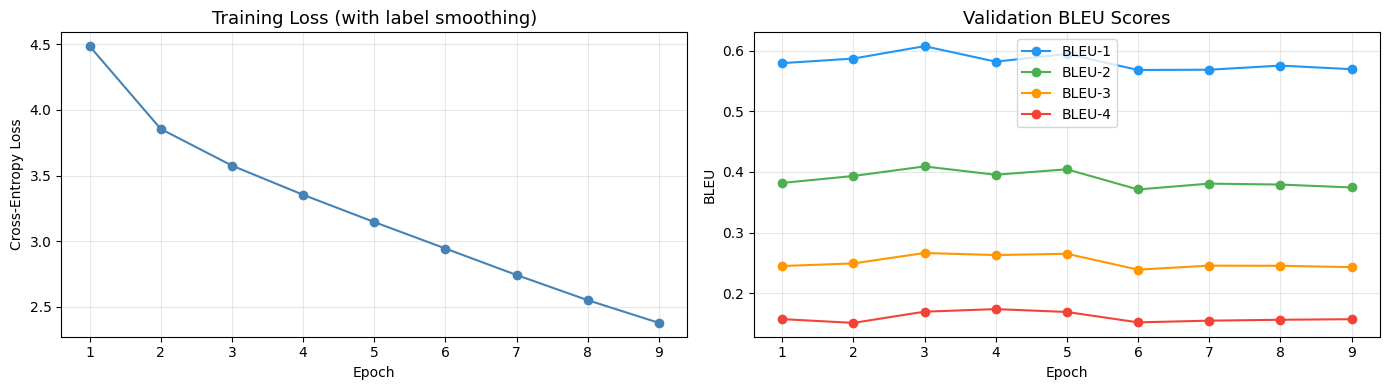

In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss (with label smoothing)", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

for key, label, color in [
    ("val_bleu1", "BLEU-1", "#2196F3"),
    ("val_bleu2", "BLEU-2", "#4CAF50"),
    ("val_bleu3", "BLEU-3", "#FF9800"),
    ("val_bleu4", "BLEU-4", "#F44336"),
]:
    axes[1].plot(epochs_ran, history[key], marker="o", label=label, color=color)

axes[1].set_title("Validation BLEU Scores", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BLEU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=120)
plt.show()

## 8. Final Evaluation on Test Set

In [ ]:
# Load best checkpoint
CKPT_INPUT = Path("/kaggle/input/datasets/sahaj25585973/best-result/vit_transformer_best.pth")

if BEST_CKPT.exists():
    CKPT_PATH = BEST_CKPT
    print(f"Loading checkpoint from working directory: {CKPT_PATH}")
else:
    CKPT_PATH = CKPT_INPUT
    print(f"Loading checkpoint from input directory:   {CKPT_PATH}")

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} "
      f"(val BLEU-4: {ckpt['bleu4']:.4f})")

# Greedy decoding
print("\n── Greedy decoding ──")
greedy_scores = evaluate_bleu(model, test_loader, DEVICE, method="greedy")
for k, v in greedy_scores.items():
    print(f"  {k.upper()}: {v:.4f}")

# Beam search (k=5)
print("\n── Beam search k=5 ──")
beam_scores = evaluate_bleu(model, test_loader, DEVICE, method="beam")
for k, v in beam_scores.items():
    print(f"  {k.upper()}: {v:.4f}")

# Save results
results = {
    "architecture" : "ViT-B/16 Encoder + 4-layer Transformer Decoder",
    "phase3_improvements": [
        "Transformer decoder replaces 2-layer GRU",
        "6 ViT blocks unfrozen (was 4)",
        "Label smoothing epsilon=0.1",
        "<unk> suppression in greedy and beam decoding",
        "Early stopping patience=5 on val BLEU-4",
    ],
    "best_val_bleu4" : ckpt["bleu4"],
    "test_greedy"    : greedy_scores,
    "test_beam5"     : beam_scores,
    "hyperparameters": {
        "d_model"           : 512,
        "nhead"             : 8,
        "num_decoder_layers": 4,
        "dim_feedforward"   : 2048,
        "dropout"           : 0.1,
        "n_unfreeze"        : 6,
        "label_smoothing"   : 0.1,
        "batch_size"        : BATCH_SIZE,
        "num_epochs"        : ckpt["epoch"],
        "optimizer"         : "AdamW",
        "encoder_lr"        : 1e-5,
        "decoder_lr"        : 4e-4,
        "scheduler"         : "CosineAnnealingLR",
        "unk_suppression"   : True,
    }
}
with open(SAVE_DIR / "vit_transformer_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✅ Results saved to vit_transformer_results.json")

Loading checkpoint from input directory:   /kaggle/input/datasets/sahaj25585973/best-result/vit_transformer_best.pth
Loaded best checkpoint from epoch 4 (val BLEU-4: 0.1737)

── Greedy decoding ──


  BLEU1: 0.5729
  BLEU2: 0.3902
  BLEU3: 0.2563
  BLEU4: 0.1640

── Beam search k=5 ──


  BLEU1: 0.5901
  BLEU2: 0.4074
  BLEU3: 0.2778
  BLEU4: 0.1869

✅ Results saved to vit_transformer_results.json


## 9. Qualitative Analysis — Visual Inspection

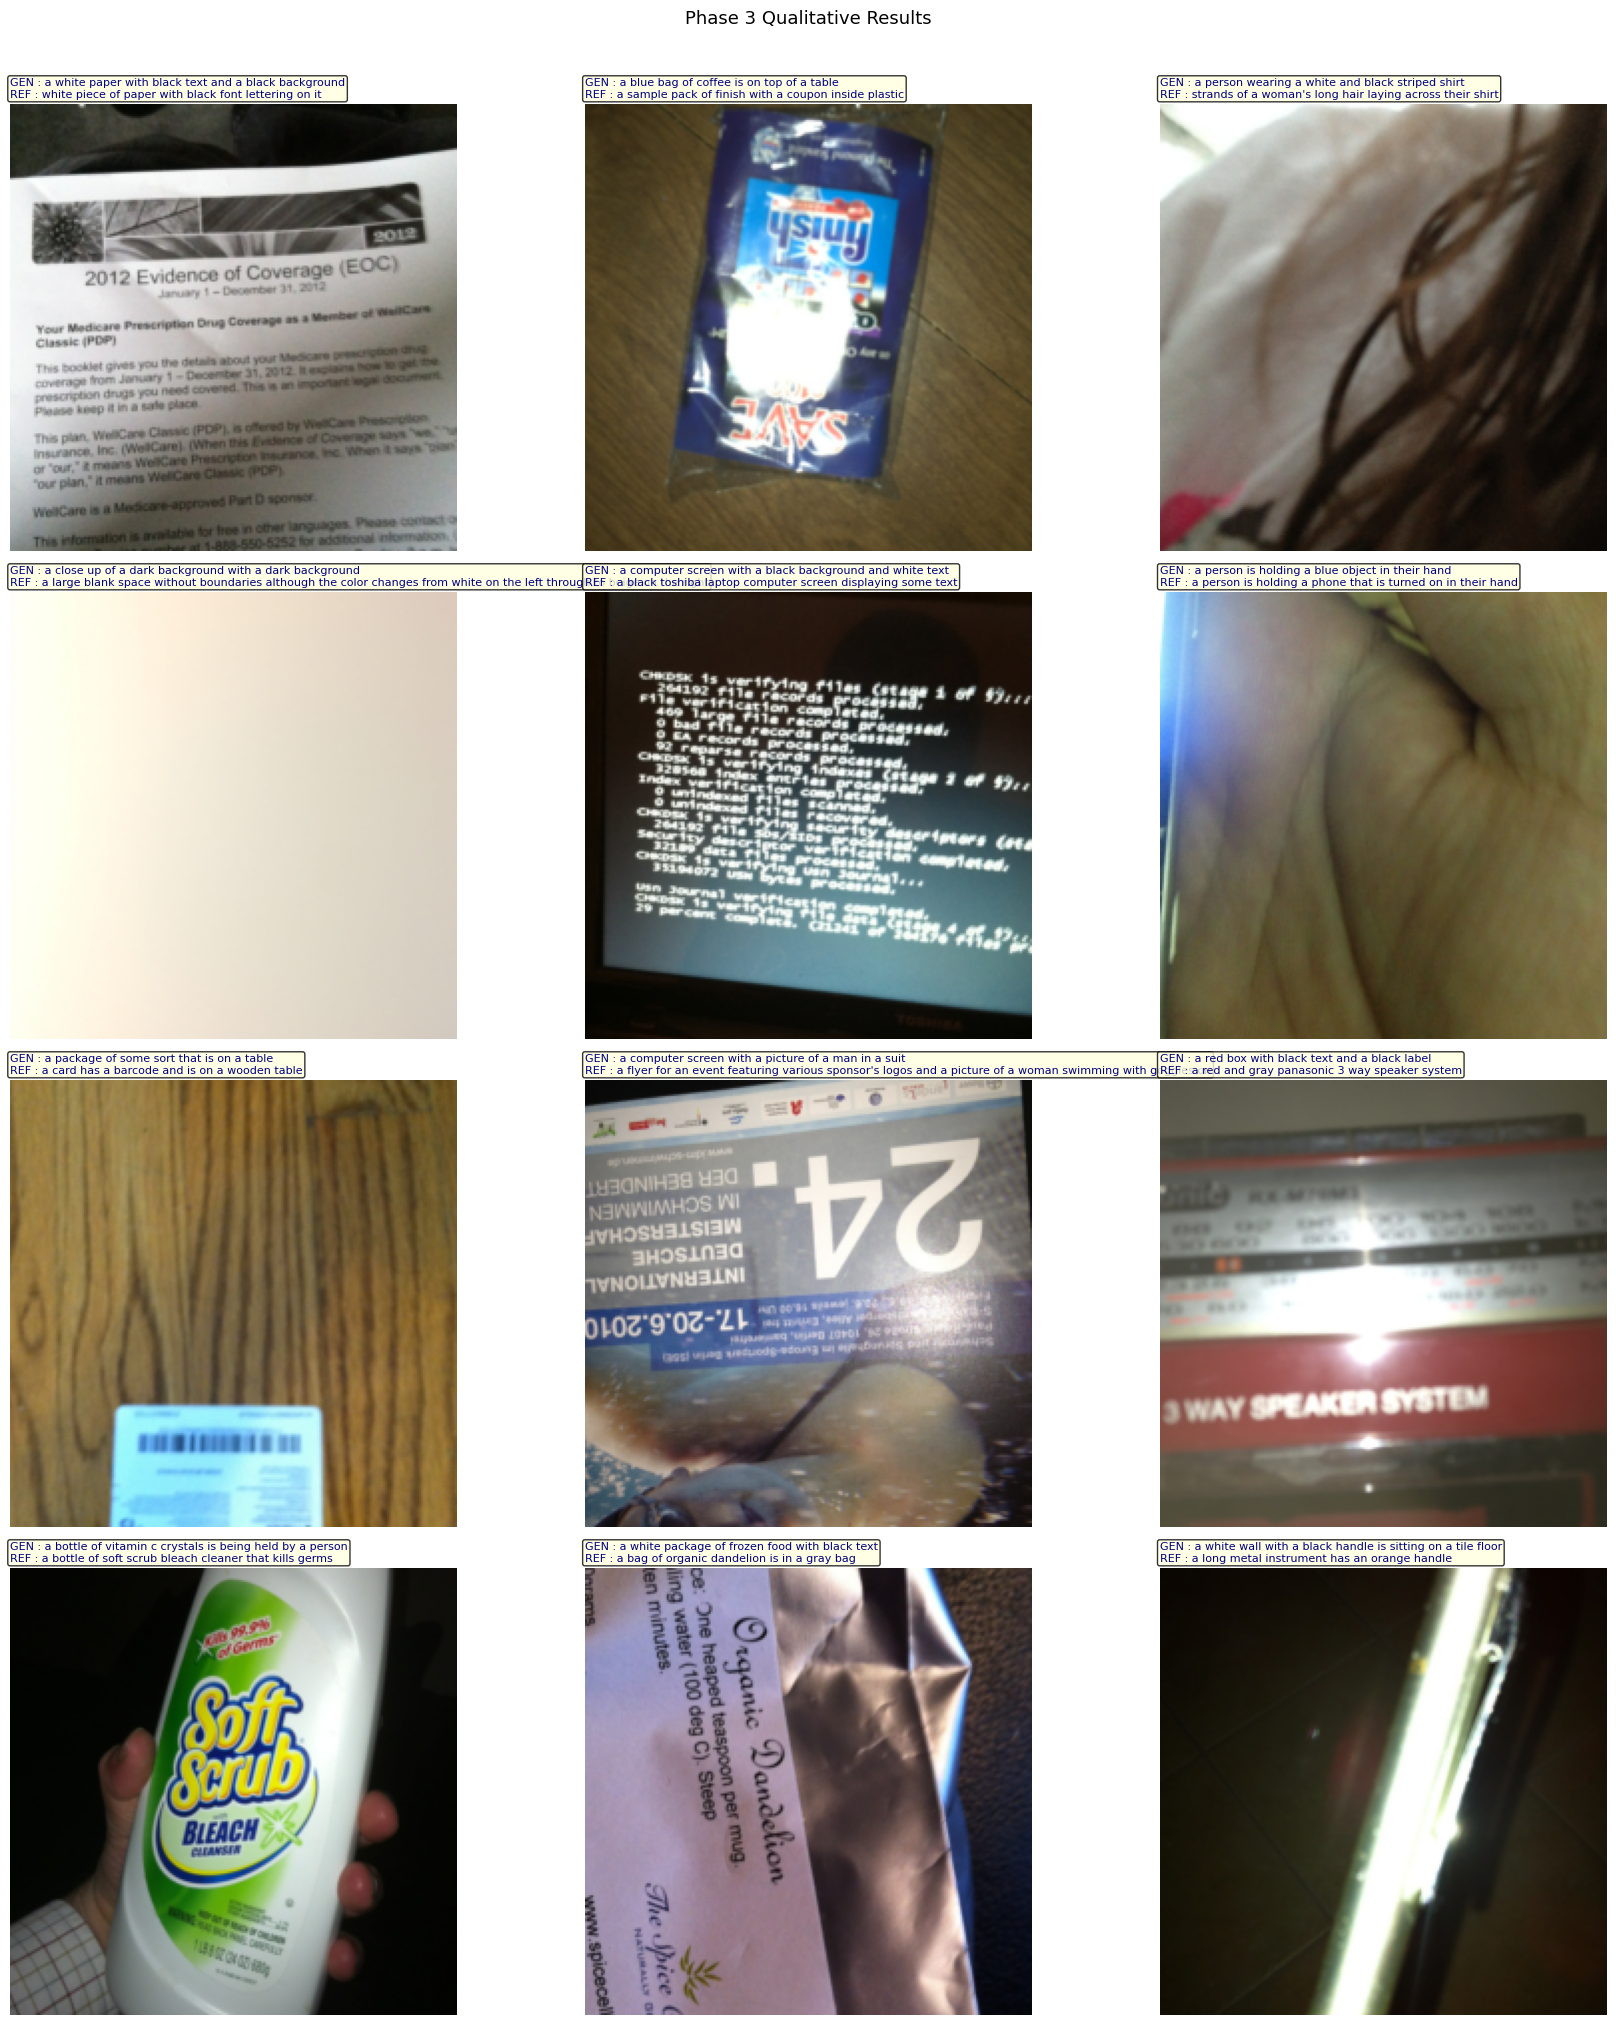

In [ ]:
def show_sample_captions(model, dataset, n=12, method="greedy", seed=0):
    """
    Display n random test images with generated vs reference captions.
    Uses greedy decoding (with <unk> suppression) as primary display.
    """
    random.seed(seed)
    indices = random.sample(range(len(dataset)), n)
    model.eval()

    inv_norm = transforms.Normalize(
        mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1/s for s in IMAGENET_STD]
    )

    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))

    for ax, idx in zip(axes.flat, indices):
        img_tensor, ref_caps, _ = dataset[idx]
        generated = model.generate(
            img_tensor.unsqueeze(0).to(DEVICE), method=method
        )
        disp = inv_norm(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(disp)
        ax.axis("off")
        title = f"GEN : {generated}\nREF : {ref_caps[0]}"
        ax.set_title(title, fontsize=8, loc="left", wrap=True,
                     color="navy",
                     bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", alpha=0.8))

    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.suptitle(
        f"Phase 3 Qualitative Results",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"qualitative_{method}.png", dpi=100, bbox_inches="tight")
    plt.show()


show_sample_captions(model, test_dataset, n=12, method="greedy")

## 10. Additional Metrics

In [ ]:
# Collect all greedy hypotheses and references from the test set
model.eval()
hypotheses  = []
references  = []
gen_lengths = []
ref_lengths = []

with torch.no_grad():
    for images, ref_caps_batch, _ in tqdm(test_loader, desc="Collecting outputs"):
        images      = images.to(DEVICE)
        encoder_out = model.encoder(images)
        for i in range(images.size(0)):
            enc       = encoder_out[i].unsqueeze(0)
            token_ids = model.decoder.greedy_decode(enc)
            hyp       = vocab.decode(token_ids)
            hypotheses.append(hyp)
            references.append(ref_caps_batch[i])
            gen_lengths.append(len(hyp.split()))
            ref_lengths.append(np.mean([len(c.split()) for c in ref_caps_batch[i]]))

print(f"Collected {len(hypotheses)} hypothesis-reference pairs.")

Collected 755 hypothesis-reference pairs.


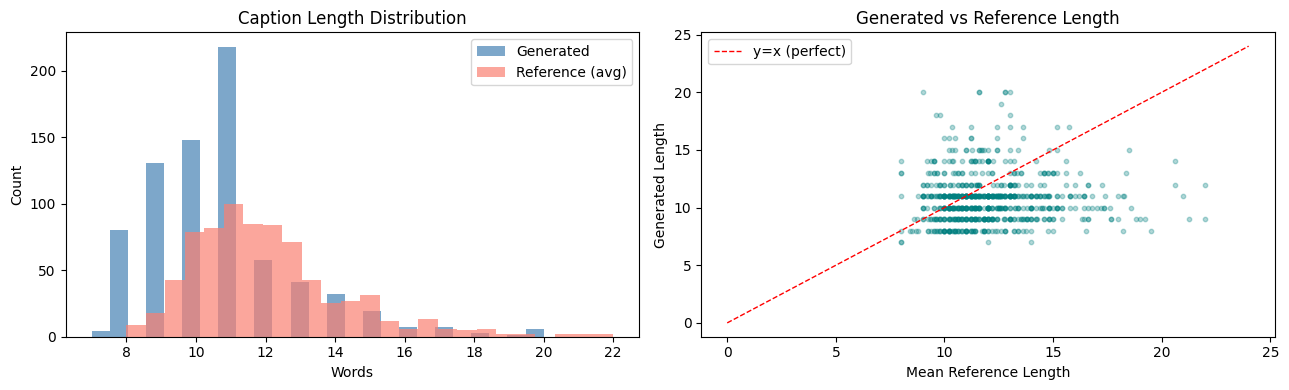

Mean generated length : 10.7 words
Mean reference length : 12.0 words


In [ ]:
# Caption length distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gen_lengths, bins=25, alpha=0.7, color="steelblue", label="Generated")
axes[0].hist(ref_lengths, bins=25, alpha=0.7, color="salmon",    label="Reference (avg)")
axes[0].set_title("Caption Length Distribution", fontsize=12)
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].scatter(ref_lengths, gen_lengths, alpha=0.3, s=10, color="teal")
lim = max(max(ref_lengths), max(gen_lengths)) + 2
axes[1].plot([0, lim], [0, lim], "r--", lw=1, label="y=x (perfect)")
axes[1].set_title("Generated vs Reference Length", fontsize=12)
axes[1].set_xlabel("Mean Reference Length")
axes[1].set_ylabel("Generated Length")
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / "length_analysis.png", dpi=120)
plt.show()

print(f"Mean generated length : {np.mean(gen_lengths):.1f} words")
print(f"Mean reference length : {np.mean(ref_lengths):.1f} words")